# Semana 5 - Clase 1
## Temas Selectos Proceso Químicos: Análisis de Datos con Python

# Análisis estadístico

In [ ]:
from IPython.display import IFrame

pdf_url = "https://raw.githubusercontent.com/marinlopabi/Temas_Selectos_PQ_26-I/refs/heads/main/Datos-IQ-Esta.pdf"
viewer = "https://drive.google.com/viewerng/viewer?embedded=true&url=" + pdf_url

IFrame(viewer, width=1000, height=900)

## Ejemplo 2
\begin{bmatrix}
26.1 & 26.0 & 14.5 & 29.3 & 19.7 \\
22.1 & 21.2 & 26.6 & 31.9 & 25.0 \\
15.9 & 20.8 & 20.2 & 17.8 & 13.3 \\
25.6 & 26.5 & 15.7 & 22.1 & 13.8 \\
29.0 & 21.3 & 23.5 & 22.1 & 10.2
\end{bmatrix}







In [ ]:
import numpy as np

 Calcula los siguientes **estadísticos descriptivos**:

   **(a) Globales (considerando todos los datos como un solo conjunto):**
   - Tamaño de la muestra \(n\)
   - Mínimo, máximo y rango
   - Media y mediana
   - Varianza y desviación estándar **muestral** (`ddof=1`)
   - Cuartiles \(Q1, Q2, Q3\) y el **IQR**
   - Coeficiente de variación (CV)

   **(b) Por columnas (cada columna como un conjunto de datos):**
   - Media, mediana y desviación estándar muestral de cada columna

3. Identifica **valores atípicos (outliers)** usando el criterio del IQR:
   - Límite inferior: $LI = Q1 - 1.5 \cdot IQR$
   - Límite superior: $LS = Q3 + 1.5 \cdot IQR$








In [ ]:
datos =  [
    26.1, 26.0, 14.5, 29.3, 19.7,
    22.1, 21.2, 26.6, 31.9, 25.0,
    15.9, 20.8, 20.2, 17.8, 13.3,
    25.6, 26.5, 15.7, 22.1, 13.8,
    29.0, 21.3, 23.5, 22.1, 10.2
]


In [ ]:
f = np.array(datos)

n = f.size # tamaño del conjunto de datos
media = f.mean()
mediana = np.median(f)

# Varianza y desviación estándar
var_pob = f.var(ddof=0)      # poblacional
std_pob = f.std(ddof=0)

var_mues = f.var(ddof=1)      # muestra
std_mues = f.std(ddof=1)


minimo = f.min()
maximo = f.max()
rango = maximo - minimo


q1, q2, q3 = np.percentile(f, [25, 50, 75])
iqr = q3 - q1
li = q1 - 1.5 * iqr
ls = q3 + 1.5 * iqr
outliers = f[(f < li) | (f > ls)]
cvf = std_mues / media * 100

In [ ]:
print("n =", n)
print("Min =", minimo, "Max =", maximo, "Rango =", rango)
print("Media =", media, "Mediana =", mediana)
print(f"Var(muestral) = {var_pob:.4f}  Std(muestral) = {std_pob:.2f}")
print("Q1, Q2, Q3 =", q1, q2, q3, "IQR =", iqr)
print("Outliers =", outliers)
print(f"CV(%) = {cvf:.2f}")


n = 25
Min = 10.2 Max = 31.9 Rango = 21.7
Media = 21.608 Mediana = 22.1
Var(muestral) = 29.5591  Std(muestral) = 5.44
Q1, Q2, Q3 = 17.8 22.1 26.0 IQR = 8.2
Outliers = []
CV(%) = 25.68


# Gráficos útiles en estadística

# 📦 Paquete Matplotlib

Matplotlib es utilizada para crear gráficos estáticos, animados e interactivos de manera sencilla y personalizable.
Está diseñada para trabajar de forma similar a MATLAB y se integra fácilmente con NumPy y pandas.

In [ ]:
import matplotlib.pyplot as plt

## Histograma

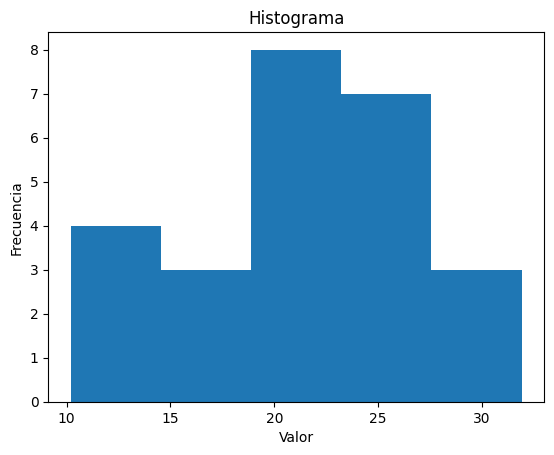

In [ ]:
plt.hist(datos, bins=5)   # ¿Qué bins son razonables?
plt.title("Histograma")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.show()

| Argumento         | Descripción                                                                                       |
| ----------------- | ------------------------------------------------------------------------------------------------- |
| **`x`**           | Datos de entrada (lista, arreglo de NumPy o serie de pandas).                                     |
| **`bins`**        | Número de barras o bordes de los intervalos. Puede ser un número (ej. 10) o una lista de límites. |
| **`range`**       | Par `(min, max)` que define el rango de los datos a considerar.                                   |
| **`density`**     | Si `True`, normaliza el histograma para representar densidades (área total = 1).                  |
| **`weights`**     | Arreglo de pesos para cada valor de `x`.                                                          |
| **`cumulative`**  | Si `True`, muestra frecuencias acumuladas.                                                        |
| **`histtype`**    | Tipo de histograma: `'bar'`, `'barstacked'`, `'step'`, `'stepfilled'`.                            |
| **`color`**       | Color de las barras (ej. `'skyblue'`, `'red'`, etc.).                                             |
| **`label`**       | Etiqueta para la leyenda.                                                                         |
| **`alpha`**       | Transparencia de las barras (0 = transparente, 1 = opaco).                                        |
| **`edgecolor`**   | Color del borde de las barras.                                                                    |
| **`linewidth`**   | Grosor del borde de las barras.                                                                   |
| **`orientation`** | `'vertical'` (por defecto) o `'horizontal'`.                                                      |
| **`rwidth`**      | Relación de ancho de las barras respecto al espacio disponible (útil para dejar separación).      |

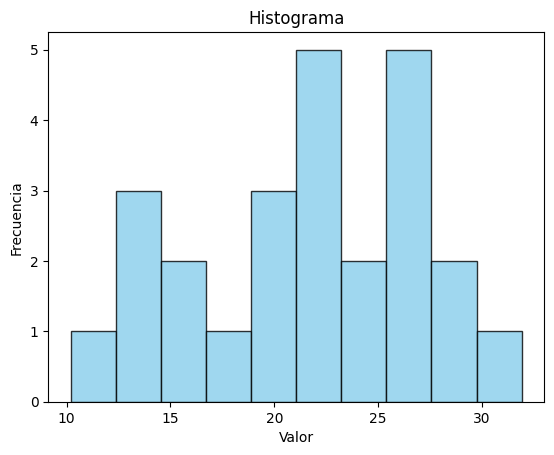

In [ ]:
plt.hist(datos, bins=10, color="skyblue", edgecolor="black", alpha=0.8)
plt.title("Histograma")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.show()


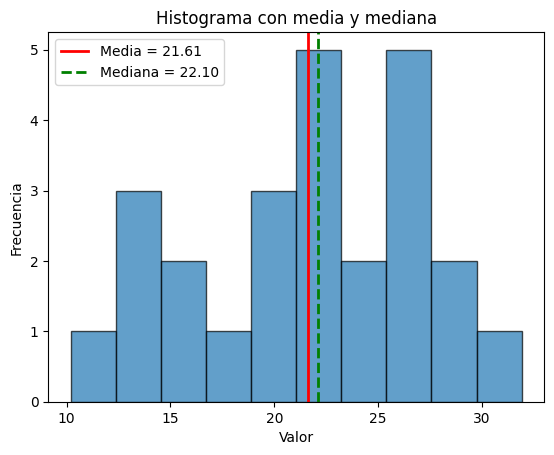

In [ ]:
media = np.mean(datos)
mediana = np.median(datos)

plt.hist(datos, bins=10, edgecolor="black", alpha=0.7)
plt.axvline(media, color="red", linewidth=2, label=f"Media = {media:.2f}")
plt.axvline(mediana, color="green", linewidth=2, linestyle="--", label=f"Mediana = {mediana:.2f}")
plt.title("Histograma con media y mediana")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


### Para guardar la figura creada

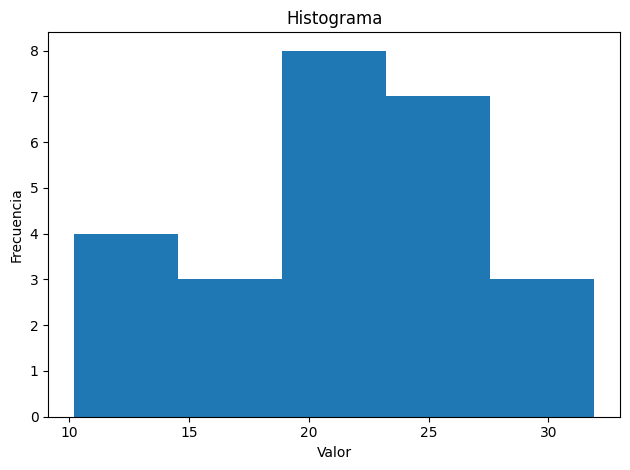

In [ ]:
import os

os.makedirs("figuras", exist_ok=True)

plt.hist(datos, bins=5)
plt.title("Histograma")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.tight_layout()

plt.savefig("figuras/figura.png", dpi=300, bbox_inches="tight")
plt.savefig("figuras/figura.pdf", bbox_inches="tight")

plt.show()
plt.close()


## Boxplot / gráfico de cajas

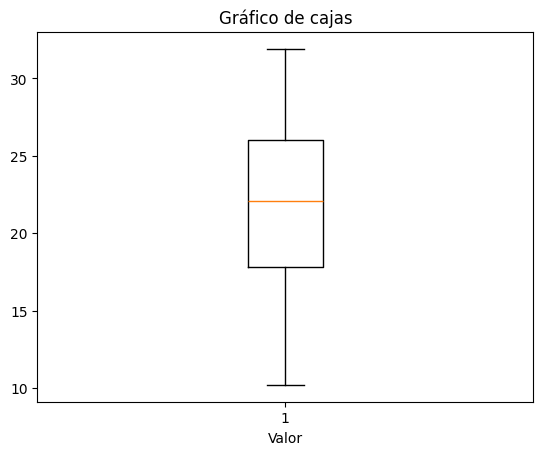

In [ ]:
plt.boxplot(datos)
plt.title("Gráfico de cajas")
plt.xlabel("Valor")
plt.show()


| Argumento          | Descripción                                                                                                      |
| ------------------ | ---------------------------------------------------------------------------------------------------------------- |
| **`x`**            | Datos a graficar. Puede ser una lista, arreglo NumPy o una lista de listas (para varios grupos).                 |
| **`notch`**        | Si es `True`, muestra una muesca (notch) en la caja indicando un intervalo de confianza alrededor de la mediana. |
| **`vert`**         | Si es `True` (por defecto), el boxplot es vertical; si es `False`, es horizontal.                                |
| **`patch_artist`** | Si es `True`, las cajas se rellenan con color.                                                                   |
| **`widths`**       | Ancho de las cajas.                                                                                              |
| **`showmeans`**    | Si es `True`, muestra el valor medio con un símbolo adicional.                                                   |
| **`showfliers`**   | Si es `False`, no muestra los valores atípicos (*outliers*).                                                     |
| **`labels`**       | Etiquetas para cada grupo de datos (por ejemplo, nombres de categorías).                                         |
| **`boxprops`**     | Diccionario para personalizar el estilo de las cajas (color, borde, relleno, etc.).                              |
| **`medianprops`**  | Diccionario para personalizar la línea de la mediana.                                                            |
| **`flierprops`**   | Diccionario para personalizar los puntos atípicos.                                                               |
| **`meanprops`**    | Diccionario para personalizar el marcador del promedio.                                                          |


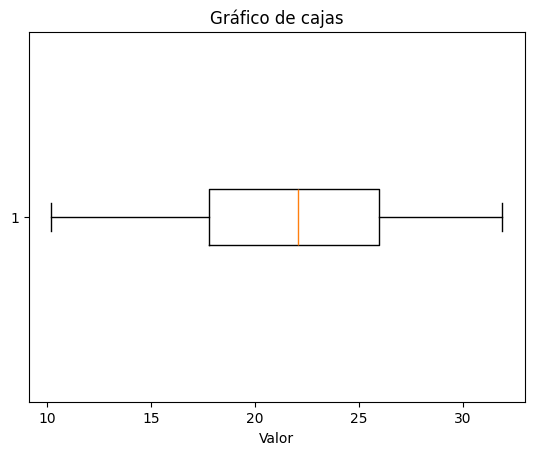

In [ ]:
plt.boxplot(datos, vert=False)
plt.title("Gráfico de cajas")
plt.xlabel("Valor")
plt.show()


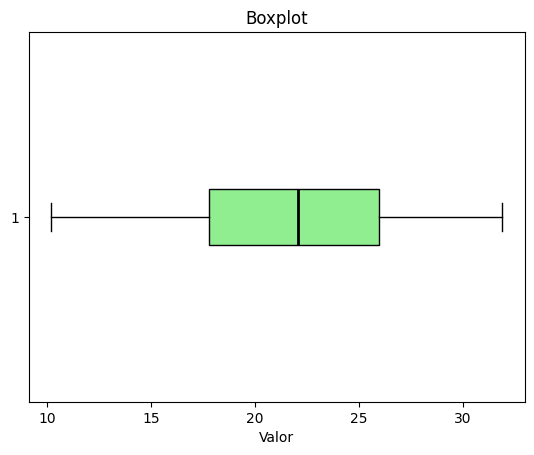

In [ ]:
plt.boxplot(
    datos,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="lightgreen"),
    medianprops=dict(color="black", linewidth=2)
)
plt.title("Boxplot")
plt.xlabel("Valor")
plt.show()


# Ejemplo. Contaminantes CDMX

In [ ]:
import pandas as pd

ruta='https://raw.githubusercontent.com/marinlopabi/Temas_Selectos_PQ_26-I/refs/heads/main/ARCHIVOS/contaminantes_CDMX.csv'
df = pd.read_csv(ruta)
df.head()

,fecha,CO,NO,NO2,NOX,O3,PM10,PM25,SO2
0,2015-01-01,1.050696,22.765528,24.225155,46.987578,23.175150,105.573684,78.953405,11.554723
1,2015-01-02,0.807585,32.249608,21.554160,53.800628,17.268366,36.687845,15.449438,1.895052
2,2015-01-03,0.640755,21.686916,19.394081,41.071651,15.486486,29.269022,12.915129,1.436937
3,2015-01-04,0.726940,24.606272,19.560976,44.165505,17.329032,39.961538,16.838284,1.809061
4,2015-01-05,0.530815,11.443182,20.990260,32.439935,14.470588,31.855643,12.667774,8.315789


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3073 entries, 0 to 3072
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   fecha   3073 non-null   object 
 1   CO      3073 non-null   float64
 2   NO      3073 non-null   float64
 3   NO2     3073 non-null   float64
 4   NOX     3073 non-null   float64
 5   O3      3073 non-null   float64
 6   PM10    3073 non-null   float64
 7   PM25    3073 non-null   float64
 8   SO2     3073 non-null   float64
dtypes: float64(8), object(1)
memory usage: 216.2+ KB


In [ ]:
df.describe() #resumen estadístico de las variables numéricas

,CO,NO,NO2,NOX,O3,PM10,PM25,SO2
count,3073.000000,3073.000000,3073.000000,3073.000000,3073.000000,3073.000000,3073.000000,3073.000000
mean,0.481926,14.712425,23.030057,37.996908,30.486331,41.892833,21.327371,3.689885
std,0.205181,8.857507,6.754973,14.795599,9.023384,16.047342,8.796122,3.490277
min,0.115917,1.168000,8.061630,9.983402,3.226054,8.218487,2.849315,0.630435
25%,0.327215,8.018735,18.188498,26.938073,23.923077,29.483986,15.344720,1.557047
50%,0.444033,12.669596,22.421517,35.880223,29.838384,40.040856,20.550000,2.484034
75%,0.597009,19.386091,26.854167,46.739777,36.216012,52.708716,26.212963,4.377049
max,1.831818,75.806548,72.193452,148.005952,67.443750,115.334071,86.909910,31.461741


| **Método**             | **Descripción**                                                                 |
|------------------------|----------------------------------------------------------------------------------|
| `count`                | Número de valores que no son nulos.                                              |
| `describe`             | Calcula un conjunto de estadísticas de resumen.                                 |
| `min`, `max`           | Calcula los valores mínimo y máximo.                                            |
| `argmin`, `argmax`     | Calcula ubicaciones de índice (enteros) en las que se obtienen los valores mínimo o máximo, respectivamente; no está disponible con objetos DataFrame. |
| `idxmin`, `idxmax`     | Calcula etiquetas de índice en las que se obtienen los valores mínimo o máximo, respectivamente. |
| `quantile`             | Calcula el cuantil de muestra entre 0 y 1 (valor predeterminado: 0.5).           |
| `sum`                  | Suma de valores.                                                                |
| `mean`                 | Promedio de valores.                                                            |
| `median`               | Media aritmética (50 % cuantil) de valores.                                     |
| `mad`                  | Desviación media absoluta del valor promedio.                                   |
| `prod`                 | Producto de todos los valores.                                                  |
| `var`                  | Varianza de los valores de muestra.                                             |
| `std`                  | Desviación estándar de los valores de muestra.                                  |
| `skew`                 | Asimetría (tercer momento) de los valores de muestra.                           |
| `kurt`                 | Curtosis (cuarto momento) de los valores de muestra.                            |
| `cumsum`               | Suma acumulada de los valores.                                                  |
| `cummin`, `cummax`     | Mínimo o máximo acumulado de los valores, respectivamente.                      |
| `cumprod`              | Producto acumulado de valores.                                                  |
| `diff`                 | Calcula la primera diferencia aritmética (útil para series temporales).         |
| `pct_change`           | Calcula cambios de porcentaje.                                                  |


In [ ]:
df.min()


,0
fecha,2015-01-01
CO,0.115917
NO,1.168
NO2,8.06163
NOX,9.983402
O3,3.226054
PM10,8.218487
PM25,2.849315
SO2,0.630435


In [ ]:
df.max()

,0
fecha,2023-05-31
CO,1.831818
NO,75.806548
NO2,72.193452
NOX,148.005952
O3,67.44375
PM10,115.334071
PM25,86.90991
SO2,31.461741


In [ ]:
df['CO']

,CO
0,1.050696
1,0.807585
2,0.640755
3,0.726940
4,0.530815
...,...
3068,0.256722
3069,0.286826
3070,0.482077
3071,0.441455


## Ejercicio: Elegir un contaminante, obtener su histograma y diagrama de cajas.

- Indica si la distribución parece simétrica o sesgada.
- Identifica si existen valores atípicos.

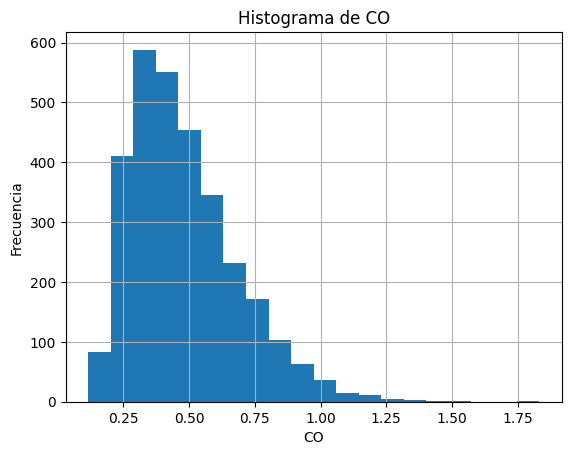

In [ ]:
# Histograma
plt.hist(df['CO'], bins=20)
plt.title("Histograma de CO")
plt.xlabel("CO")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

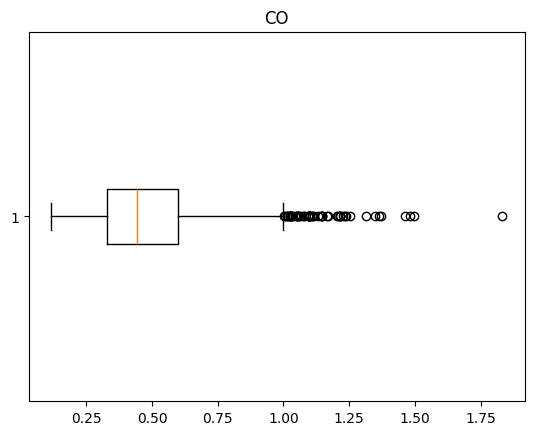

In [ ]:
# Boxplot
plt.boxplot(df['CO'], vert=False)
plt.title("CO")
plt.show()


# Graficar todos los datos

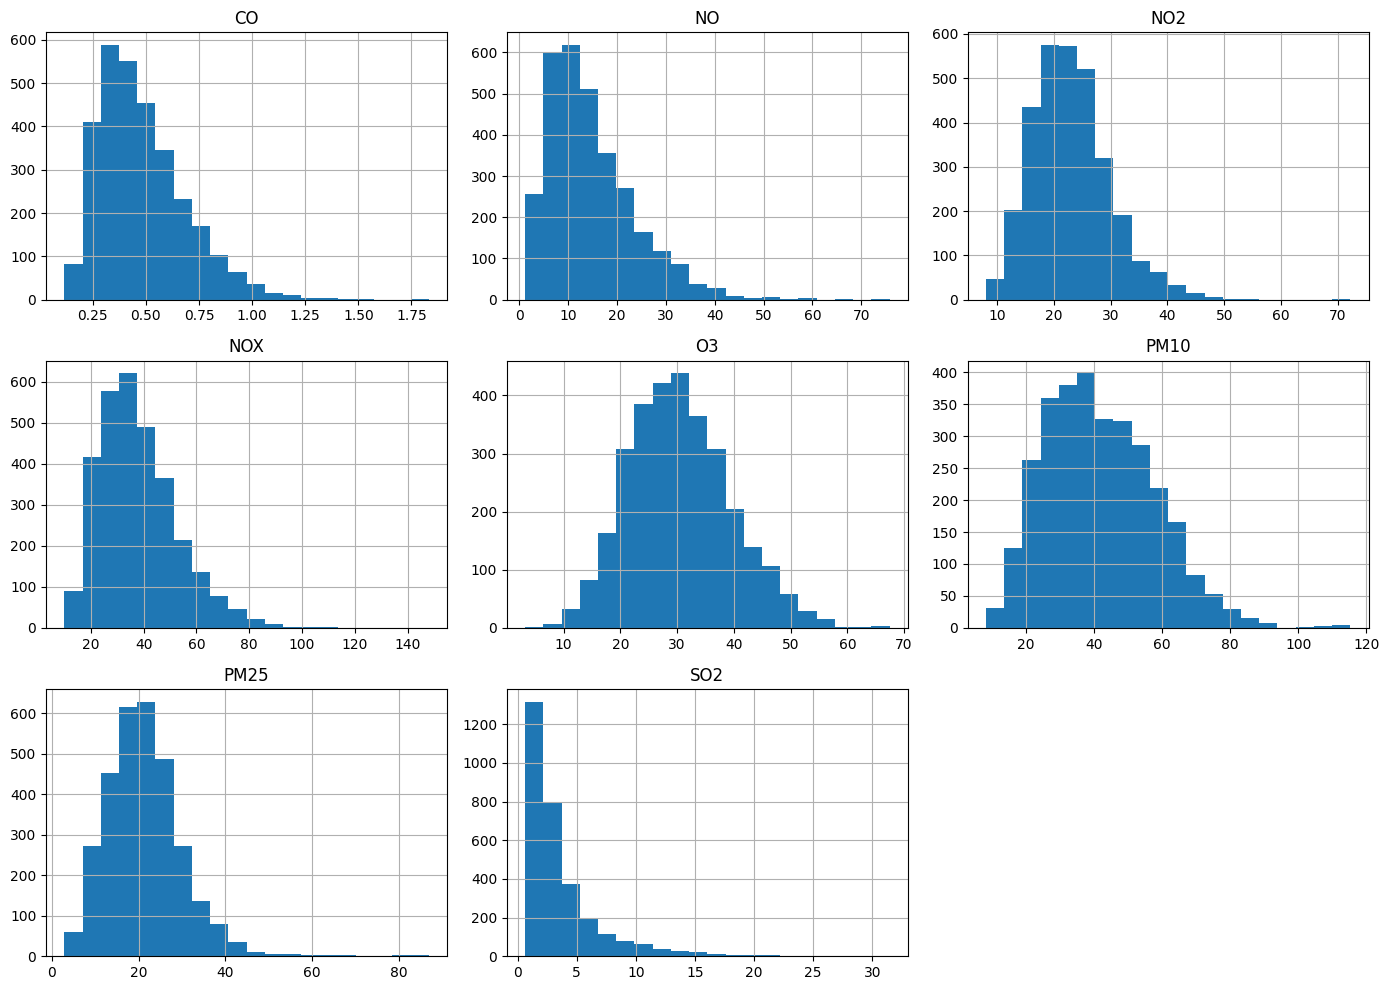

In [ ]:
df.hist(bins=20, figsize=(14,10))
plt.tight_layout()
plt.show()


Según los histogramas, ¿Cuál(es) contaminates presentan asimetría positiva?¿Cuál(es) no?,

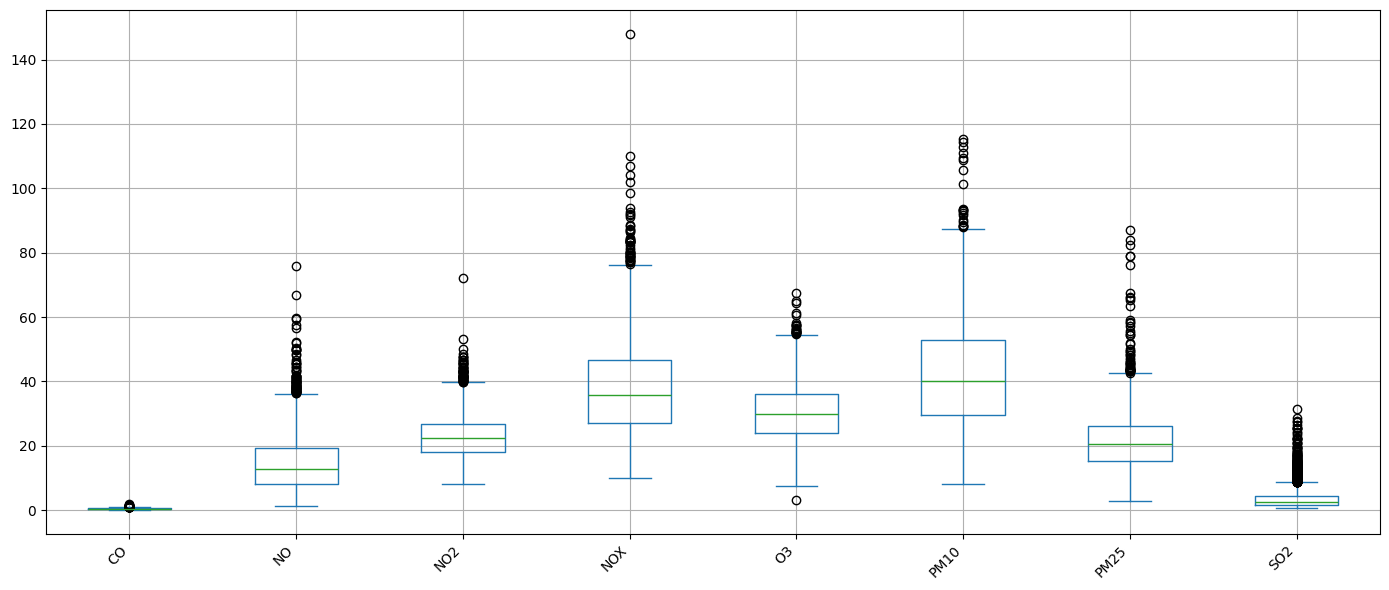

In [ ]:
cols_num = df.select_dtypes(include="number")
cols_num.plot(kind="box", figsize=(14,6), grid=True)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



# UN AÑO

In [ ]:
df.iloc[0:365]

,fecha,CO,NO,NO2,NOX,O3,PM10,PM25,SO2
0,2015-01-01,1.050696,22.765528,24.225155,46.987578,23.175150,105.573684,78.953405,11.554723
1,2015-01-02,0.807585,32.249608,21.554160,53.800628,17.268366,36.687845,15.449438,1.895052
2,2015-01-03,0.640755,21.686916,19.394081,41.071651,15.486486,29.269022,12.915129,1.436937
3,2015-01-04,0.726940,24.606272,19.560976,44.165505,17.329032,39.961538,16.838284,1.809061
4,2015-01-05,0.530815,11.443182,20.990260,32.439935,14.470588,31.855643,12.667774,8.315789
...,...,...,...,...,...,...,...,...,...
360,2015-12-27,0.450000,7.866822,14.696262,22.553738,22.619485,33.779817,10.474926,1.466981
361,2015-12-28,0.896782,31.277778,31.409722,62.724537,22.707780,51.736973,18.164557,2.401961
362,2015-12-29,0.833744,30.171806,28.310573,58.477974,20.016304,50.809013,19.081522,2.158242
363,2015-12-30,0.999153,33.464646,33.489899,66.954545,30.935010,59.109474,26.777778,5.348485


In [ ]:
CO_2015 = df['CO'].iloc[0:365]
CO_2015

,CO
0,1.050696
1,0.807585
2,0.640755
3,0.726940
4,0.530815
...,...
360,0.450000
361,0.896782
362,0.833744
363,0.999153
